# Chapter 04: MNIST foundations

In [1]:
! pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 17.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.8 MB/s eta 0:00:0000:01


In [2]:
from fastai.vision.all import *
from fastbook import *

matplotlib.rc('image', cmap='Greys')

## Section: Images & Tensors

### Ex 1: Images as data

In [10]:
samples = untar_data(URLs.MNIST_SAMPLE)
samples

<div><progress max="3214948" value="3219456"></progress> 100.14% [3219456/3214948 00:00&lt;00:00]</div>

Path('/root/.fastai/data/mnist_sample')

In [11]:
samples.ls()

[Path('/root/.fastai/data/mnist_sample/valid'), Path('/root/.fastai/data/mnist_sample/labels.csv'), Path('/root/.fastai/data/mnist_sample/train')]

In [12]:
Path.BASE_PATH = samples
samples

Path('.')

In [18]:
!ls $samples/'train/3'

10000.png  17470.png  25210.png  33283.png  41136.png  48932.png  5640.png
10011.png  17471.png  25222.png  33299.png  41143.png  48935.png  56420.png
10031.png  17491.png  25225.png  33316.png  41165.png  48965.png  5642.png
10034.png  17496.png  25231.png  3332.png   41171.png  48974.png  56434.png
10042.png  17509.png  25245.png  33331.png  41212.png  48978.png  56437.png
10052.png  17521.png  2524.png	 33344.png  4121.png   48981.png  56448.png
10074.png  17526.png  25257.png  33351.png  41225.png  4898.png   56449.png
1007.png   17553.png  25266.png  33357.png  41229.png  48995.png  56457.png
10091.png  17569.png  25282.png  3336.png   41233.png  48998.png  56474.png
10093.png  1756.png   25284.png  33371.png  41267.png  49006.png  56475.png
10097.png  17574.png  25291.png  33399.png  41283.png  49018.png  56488.png
10099.png  17575.png  25296.png  33400.png  41287.png  49020.png  56492.png
10116.png  17580.png  2529.png	 33407.png  41299.png  49054.png  56495.png
10125.png  17582

In [19]:
train_threes = (samples / 'train/3').ls().sorted()
train_sevens = (samples / 'train/7').ls().sorted()
valid_threes = (samples / 'valid/3').ls().sorted()
valid_sevens = (samples / 'valid/7').ls().sorted()

len(train_threes), len(train_sevens), len(valid_threes), len(valid_sevens)

(6131, 6265, 1010, 1028)

In [24]:
a_3 = Image.open(train_threes[0])
a_3

In [27]:
# as a numpy array
a_3_np = np.array(a_3)
a_3_np

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118, 219, 166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254, 254, 254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  18, 232, 254, 254, 254, 254, 254, 238,  70,   0

In [28]:
# as a pytorch tensor
a_3_tens = tensor(a_3)
a_3_tens

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118, 219, 166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254, 254, 254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  18, 232, 254, 254, 254, 254, 254, 238,  

In [37]:
a_3_np[10:16, 10:16], a_3_tens[10:16, 10:16]

(array([[  0,   0,   0,  24, 209, 254],
        [  0,   0,  91, 137, 253, 254],
        [ 40, 214, 250, 254, 254, 254],
        [ 81, 247, 254, 254, 254, 254],
        [  0, 110, 246, 254, 254, 254],
        [  0,   0,  73,  89,  89,  93]], dtype=uint8),
 tensor([[  0,   0,   0,  24, 209, 254],
         [  0,   0,  91, 137, 253, 254],
         [ 40, 214, 250, 254, 254, 254],
         [ 81, 247, 254, 254, 254, 254],
         [  0, 110, 246, 254, 254, 254],
         [  0,   0,  73,  89,  89,  93]], dtype=torch.uint8))

### Ex 2: From images to tensors

In [44]:
train_3_tens = [tensor(Image.open(p)) for p in train_threes]
train_7_tens = [tensor(Image.open(p)) for p in train_sevens]

len(train_3_tens), len(train_7_tens)

(6131, 6265)

In [52]:
stacked_train_3 = torch.stack(train_3_tens).float() / 255
stacked_train_7 = torch.stack(train_7_tens).float() / 255

(stacked_train_3.shape, stacked_train_3.ndim), (stacked_train_7.shape, stacked_train_7.ndim)

((torch.Size([6131, 28, 28]), 3), (torch.Size([6265, 28, 28]), 3))

In [51]:
stacked_train_3[0, 10:16, 10:16]

tensor([[0.0000, 0.0000, 0.0000, 0.0941, 0.8196, 0.9961],
        [0.0000, 0.0000, 0.3569, 0.5373, 0.9922, 0.9961],
        [0.1569, 0.8392, 0.9804, 0.9961, 0.9961, 0.9961],
        [0.3176, 0.9686, 0.9961, 0.9961, 0.9961, 0.9961],
        [0.0000, 0.4314, 0.9647, 0.9961, 0.9961, 0.9961],
        [0.0000, 0.0000, 0.2863, 0.3490, 0.3490, 0.3647]])

In [61]:
stacked_train_7.dtype

torch.float32

## Section: Baseline Classifier

### Ex 3: The ideal digit

What would be the ideal digit?

One answer is the average value/intensity of each of the 28 pixels across all the training data for each category.

In [77]:
ideal_3 = stacked_train_3.mean(0)
ideal_7 = stacked_train_7.mean(0)

ideal_3.shape, ideal_7.shape

(torch.Size([28, 28]), torch.Size([28, 28]))

<Axes: >

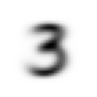

In [78]:
show_image(ideal_3)

<Axes: >

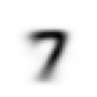

In [79]:
show_image(ideal_7)

Blurry regions => areas where intensity differs significantly across images

Darker regions => areas where pixels consistently have similar intensity across images

### Ex 4: Distance metrics — L1 and L2

In [111]:
valid_threes = (samples / 'valid/3').ls().sorted()
valid_sevens = (samples / 'valid/7').ls().sorted()

len(valid_threes), len(valid_sevens)

(1010, 1028)

In [114]:
valid_3_tens = [tensor(Image.open(p)) for p in valid_threes]
valid_7_tens = [tensor(Image.open(p)) for p in valid_sevens]

len(valid_3_tens), len(valid_7_tens)

(1010, 1028)

In [115]:
stacked_valid_3 = torch.stack(valid_3_tens).float()/255
stacked_valid_7 = torch.stack(valid_7_tens).float()/255

stacked_valid_3.shape, stacked_valid_7.shape

(torch.Size([1010, 28, 28]), torch.Size([1028, 28, 28]))

In [116]:
a_3 = stacked_valid_3[0]
a_3.shape

torch.Size([28, 28])

In [106]:
def l1_dist(t1, t2):
    """Mean absolute error"""
    return (t1-t2).abs().mean()

def l2_dist(t1, t2):
    """Root mean squared error"""
    return (t1-t2).pow(2).mean().sqrt()

In [117]:
l1_dist(a_3, ideal_3), l1_dist(a_3, ideal_7), l2_dist(a_3, ideal_3), l2_dist(a_3, ideal_7)

(tensor(0.1280), tensor(0.1530), tensor(0.2328), tensor(0.2896))

In [118]:
# using pytorch methods
F.l1_loss(a_3, ideal_3), F.l1_loss(a_3, ideal_7), F.mse_loss(a_3, ideal_3).sqrt(), F.mse_loss(a_3, ideal_7).sqrt()

(tensor(0.1280), tensor(0.1530), tensor(0.2328), tensor(0.2896))

### Ex 5: Broadcasting and batch classification

In [136]:
def mnist_distance(a, b):
    return (a - b).abs().mean(dim=(-2,-1))

In [137]:
mnist_distance(stacked_valid_3, ideal_3)

tensor([0.1280, 0.1623, 0.1242,  ..., 0.1508, 0.1263, 0.1260])

In [143]:
def is_3(x):
    return mnist_distance(x, ideal_3) < mnist_distance(x, ideal_7)

In [145]:
is_3(stacked_valid_3)

tensor([ True,  True,  True,  ..., False,  True,  True])

In [148]:
valid_3_accuracy = is_3(stacked_valid_3).float().mean()
valid_7_accuracy = (1 - is_3(stacked_valid_7).float()).mean()

valid_3_accuracy, valid_7_accuracy

(tensor(0.9168), tensor(0.9854))

In [149]:
full_accuracy = tensor((valid_3_accuracy, valid_7_accuracy)).mean()
full_accuracy

tensor(0.9511)

#### Alternate implementation
Instead of dealing with `28x28` image matrices, extend each of them to one single vector using `torch.view()`, then compute the mean on the resulting rank-2 tensor.

In [155]:
stacked_valid_3_alt = stacked_valid_3.view(stacked_valid_3.shape[0], math.prod(stacked_valid_3.shape[-2:]))
stacked_valid_7_alt = stacked_valid_7.view(stacked_valid_7.shape[0], math.prod(stacked_valid_7.shape[-2:]))

stacked_valid_3_alt.shape, stacked_valid_7_alt.shape

(torch.Size([1010, 784]), torch.Size([1028, 784]))

In [156]:
def mnist_distance_alt(a, b):
    return (a - b).abs().mean(-1)

In [160]:
mnist_distance_alt(stacked_valid_3_alt, stacked_valid_3_alt.mean(0))

tensor([0.1284, 0.1592, 0.1193,  ..., 0.1534, 0.1228, 0.1202])

In [161]:
def is_3_alt(x):
    return mnist_distance_alt(x, stacked_valid_3_alt.mean(0)) < mnist_distance_alt(x, stacked_valid_7_alt.mean(0))

In [162]:
is_3_alt(stacked_valid_3_alt), is_3_alt(stacked_valid_7_alt)

(tensor([ True,  True,  True,  ..., False,  True,  True]),
 tensor([False, False, False,  ..., False, False, False]))

In [165]:
valid_3_acc_alt = is_3_alt(stacked_valid_3_alt).float().mean()
valid_7_acc_alt = (1 - is_3_alt(stacked_valid_7_alt).float()).mean()

valid_3_acc_alt, valid_7_acc_alt

(tensor(0.9139), tensor(0.9903))

Something made this alternate implementation give slightly different numbers, lower for validation threes and higher for validation sevens. Interesting.

In [166]:
full_acc_alt = tensor((valid_3_acc_alt, valid_7_acc_alt)).mean()
full_acc_alt

tensor(0.9521)

Ever so slightly different from the value produced by the previous implementation.

In [167]:
mnist_distance(stacked_valid_3[0], ideal_3), mnist_distance_alt(stacked_valid_3_alt[0], stacked_valid_3_alt.mean(0))

(tensor(0.1280), tensor(0.1284))